In [1]:
# Langkah 1 & 2: Install & Import (Jawaban Pertanyaan #1 & #2)
!pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Langkah 3: Download & Load CSV (Jawaban Pertanyaan #3)
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
df = pd.read_csv('survey-data.csv')
print("5 Data Pertama dari CSV:")
print(df.head())

# Langkah 4: Membuat SQLite Database (Jawaban Pertanyaan #4)
conn = sqlite3.connect('survey-data.sqlite')
df.to_sql('main', conn, if_exists='replace', index=False)
print("\nDatabase 'survey-data.sqlite' berhasil dibuat dengan tabel 'main'.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 121.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 140.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 150.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 119.9 MB/s eta 0:00:00
--2025-12-28 15:47:43--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Savin

In [2]:
# Langkah 5: Verifikasi Data Terisi (Jawaban Pertanyaan #5)
QUERY_CHECK = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY_CHECK, conn)
print("Verifikasi 5 baris pertama dari SQL:")
print(df_check)

# Langkah 6: Menghitung Baris (Jawaban Pertanyaan #6)
QUERY_COUNT = "SELECT COUNT(*) as total_rows FROM main"
df_count = pd.read_sql_query(QUERY_COUNT, conn)
print(f"\nTotal baris di tabel main: {df_count.iat[0,0]}")

# Langkah 7: List Semua Tabel (Jawaban Pertanyaan #7)
QUERY_TABLES = "SELECT name as Table_Name FROM sqlite_master WHERE type = 'table'"
print("\nDaftar Tabel di Database:")
print(pd.read_sql_query(QUERY_TABLES, conn))

Verifikasi 5 baris pertama dari SQL:
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None 

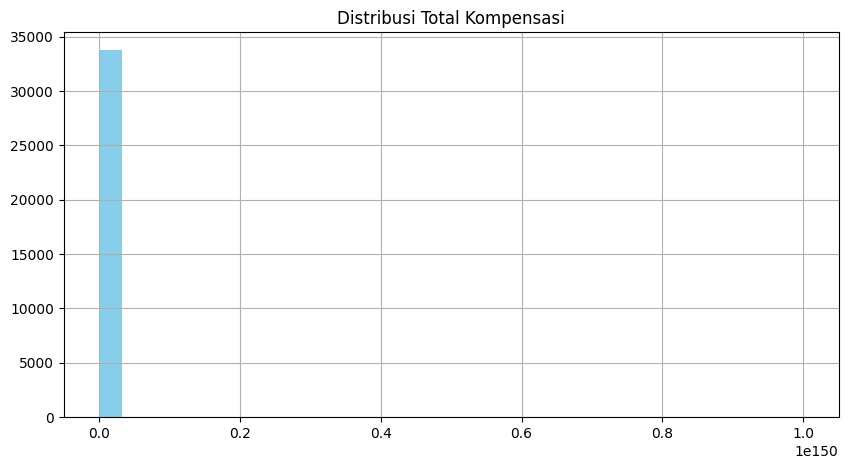

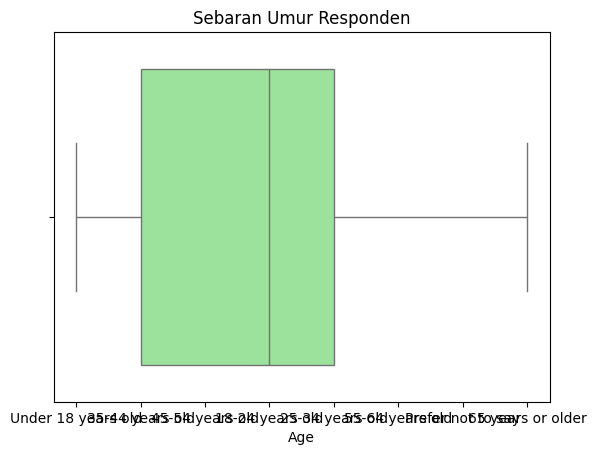

In [3]:
# Histogram CompTotal
QUERY_HIST = "SELECT CompTotal FROM main"
df_hist = pd.read_sql_query(QUERY_HIST, conn)
df_hist.hist(bins=30, figsize=(10,5), color='skyblue')
plt.title('Distribusi Total Kompensasi')
plt.show()

# Box Plot Age
QUERY_BOX = "SELECT Age FROM main"
df_box = pd.read_sql_query(QUERY_BOX, conn)
sns.boxplot(x=df_box['Age'], color='lightgreen')
plt.title('Sebaran Umur Responden')
plt.show()

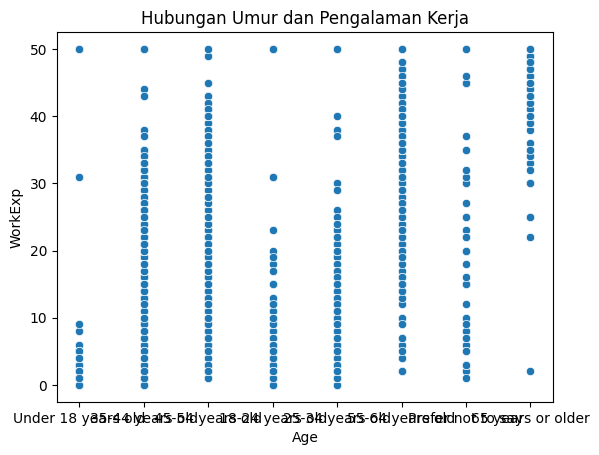

In [4]:
# Scatter Plot Age vs WorkExp
QUERY_SCATTER = "SELECT Age, WorkExp FROM main"
df_scatter = pd.read_sql_query(QUERY_SCATTER, conn)
sns.scatterplot(data=df_scatter, x='Age', y='WorkExp')
plt.title('Hubungan Umur dan Pengalaman Kerja')
plt.show()

In [ ]:
# Pastikan koneksi 'conn' masih terbuka
# Query untuk mengelompokkan Age dan menghitung jumlahnya
QUERY = """
SELECT Age, COUNT(*) as Count
FROM main
GROUP BY Age
ORDER BY Age
"""

# Menjalankan query dan menyimpannya ke DataFrame
df_age_count = pd.read_sql_query(QUERY, conn)

# Menampilkan hasil pengelompokan
print("Hasil Pengelompokan Berdasarkan Umur:")
print(df_age_count)

In [ ]:
# Visualisasi hasil grouping
plt.figure(figsize=(12,6))
plt.bar(df_age_count['Age'], df_age_count['Count'], color='coral')
plt.title('Jumlah Responden Berdasarkan Umur')
plt.xlabel('Umur')
plt.ylabel('Jumlah Responden')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()